## Install library

In [1]:
!pip install Pandas numpy seaborn matplotlib

## Import Library

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns

In [3]:
sns.set_theme(style='whitegrid')

## load Data & Inspection

In [5]:
df=pd.read_csv('SQL.csv')

In [6]:
df.head()

,order_id,order_date,order_time,store_id,city,customer_id,pizza_name,category,size,quantity,unit_price,discount,gst,total_amount,order_type,payment_method,Month,day Of Week,Hour,Discount Category
0,100170,01-01-2025,12:43:00,ST037,Hyderabad,CUST03503,Pepper Barbecue Chicken,Chicken,Personal,4,359.2,0.00,71.84,1508.64,Dine-in,Cash,January,Wednesday,12,No Discount
1,100368,01-01-2025,13:38:00,ST024,Delhi,CUST21585,Cheese n Corn,Veg,Personal,2,199.2,39.84,17.93,376.49,Delivery,UPI,January,Wednesday,13,Low Discount
2,101200,01-01-2025,20:43:00,ST022,Jaipur,CUST24682,Veg Extravaganza,Veg,Personal,3,319.2,0.00,47.88,1005.48,Dine-in,Wallet,January,Wednesday,20,No Discount
3,101601,01-01-2025,21:03:00,ST020,Delhi,CUST22560,Pepper Barbecue Chicken,Chicken,Regular,4,449.0,269.40,76.33,1602.93,Delivery,UPI,January,Wednesday,21,High Discount
4,102148,01-01-2025,19:21:00,ST013,Pune,CUST21981,Farmhouse,Veg,Regular,2,299.0,29.90,28.41,596.51,Takeaway,Wallet,January,Wednesday,19,Low Discount


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           50000 non-null  int64  
 1   order_date         50000 non-null  str    
 2   order_time         50000 non-null  str    
 3   store_id           50000 non-null  str    
 4   city               50000 non-null  str    
 5   customer_id        50000 non-null  str    
 6   pizza_name         50000 non-null  str    
 7   category           50000 non-null  str    
 8   size               50000 non-null  str    
 9   quantity           50000 non-null  int64  
 10  unit_price         50000 non-null  float64
 11  discount           50000 non-null  float64
 12  gst                50000 non-null  float64
 13  total_amount       50000 non-null  float64
 14  order_type         50000 non-null  str    
 15  payment_method     50000 non-null  str    
 16  Month              50000 non-null

In [8]:
df.describe()

,order_id,quantity,unit_price,discount,gst,total_amount,Hour
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,2.504460,446.26732,67.312267,52.443938,1101.318882,16.000400
std,14433.901067,1.115188,187.38419,88.779647,33.729290,708.313950,3.743191
min,100001.000000,1.000000,119.20000,0.000000,5.070000,106.390000,10.000000
25%,112500.750000,2.000000,303.20000,0.000000,25.770000,541.210000,13.000000
50%,125000.500000,3.000000,399.20000,35.880000,44.910000,943.110000,16.000000
75%,137500.250000,3.000000,583.70000,102.960000,71.760000,1506.960000,19.000000
max,150000.000000,4.000000,958.40000,575.040000,191.680000,4025.280000,23.000000


## Data Manipuation

In [9]:
df.isnull().sum()

order_id             0
order_date           0
order_time           0
store_id             0
city                 0
customer_id          0
pizza_name           0
category             0
size                 0
quantity             0
unit_price           0
discount             0
gst                  0
total_amount         0
order_type           0
payment_method       0
Month                0
day Of Week          0
Hour                 0
Discount Category    0
dtype: int64

## Exploartory Data Analysis

### Distribution of a Key Metric

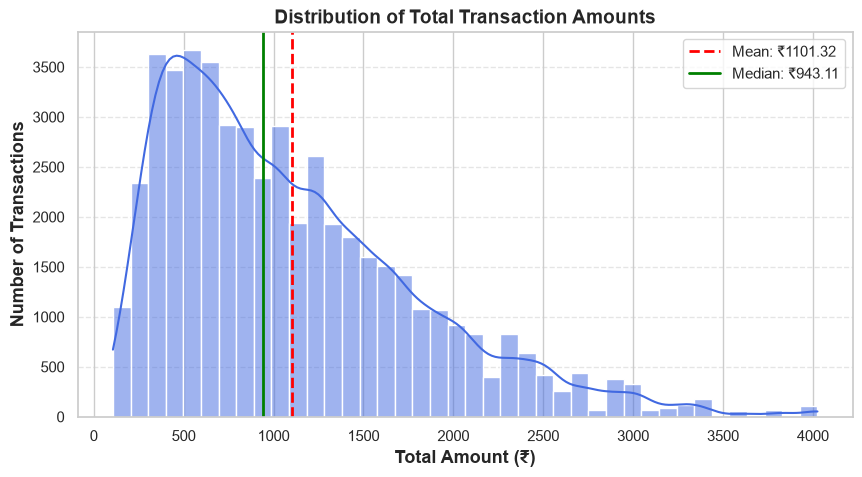

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
mean_val = df["total_amount"].mean()
median_val = df["total_amount"].median()

plt.figure(figsize=(10, 5))
sns.histplot(
    df["total_amount"], kde=True, bins=40, color="royalblue", edgecolor="white"
)
plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ₹{mean_val:.2f}",
)
plt.axvline(
    median_val,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median: ₹{median_val:.2f}",
)
plt.title("Distribution of Total Transaction Amounts",fontsize=14,fontweight="bold")
plt.xlabel("Total Amount (₹)", fontsize=13,fontweight='bold')
plt.ylabel("Number of Transactions", fontsize=13,fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Conclusion 
The Revenue distribution is heavily right-skewed, showing that the vast majority of transactions fall between ₹300 and ₹800, with a steep drop-off beyond ₹1,500.
Because of high-value transactions extending past ₹3,000, the Mean is pulled higher than the Median. The median serves as the more reliable measure of central tendency for typical customer spending.


## Averages across discrete Sizes

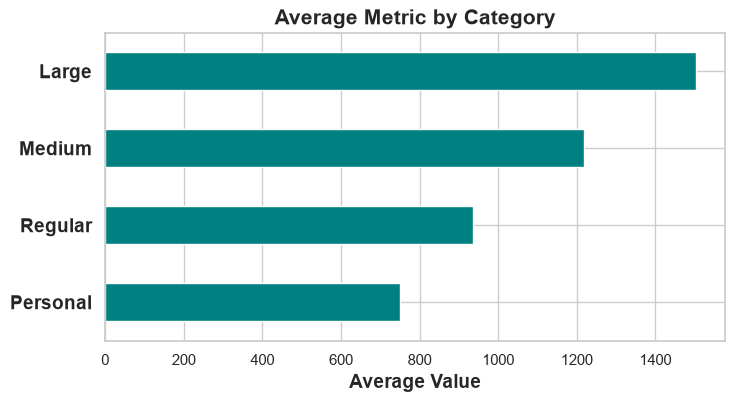

In [25]:
plt.figure(figsize=(8, 4))
avg_data = (df.groupby("size")["total_amount"].mean().sort_values())
avg_data.plot(kind="barh", color="teal")
plt.title("Average Metric by Category",fontsize=15,fontweight='bold')
plt.xlabel("Average Value",fontsize=14,fontweight='bold')
plt.ylabel('')
plt.yticks(fontsize=14,fontweight='bold')
plt.show()

### Conclusion: 
Identifies top-performing and underperforming Sizes at a glance to guide prioritized business decisions.

## Spread and Outlier Detection

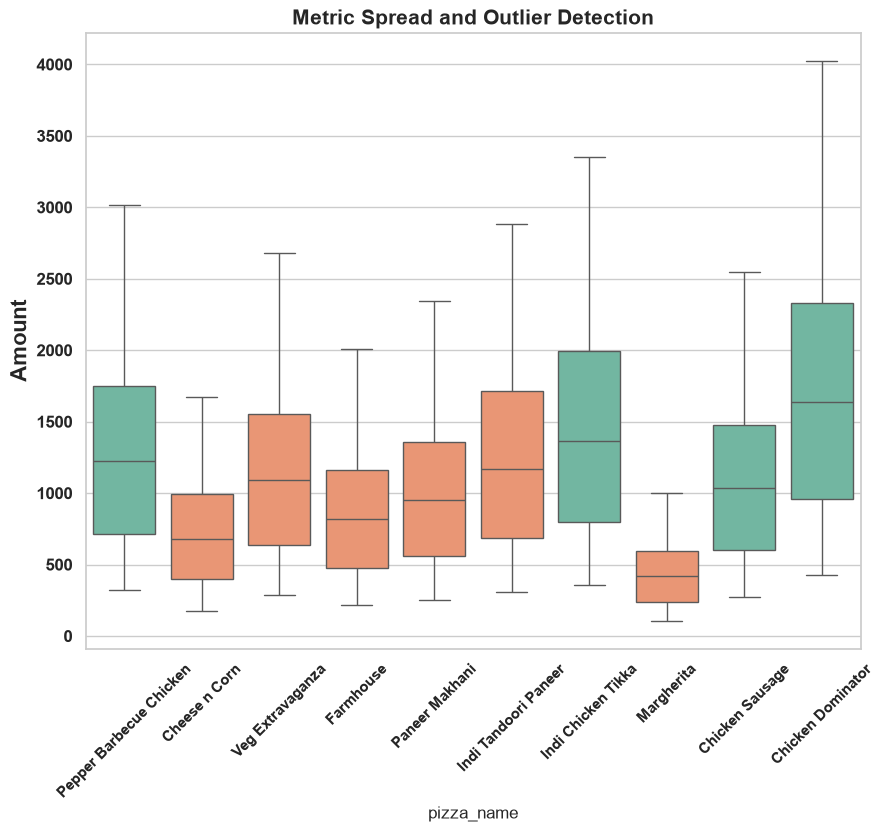

In [45]:
plt.figure(figsize=(10,8))
sns.boxplot(x="pizza_name", y="total_amount", data=df,hue='category',legend=False,palette="Set2")
plt.title("Metric Spread and Outlier Detection",fontsize=15,fontweight='bold')
plt.xticks(rotation=45,fontweight='bold')
plt.ylabel('Amount',fontsize=16,fontweight='bold')
plt.yticks(fontsize=12,fontweight='bold')
plt.show()

### Conclusion:
Reveals variability within Pizza_Name and pinpoints extreme outlier values that require further cleaning or investigation.

## Correlation Matrix

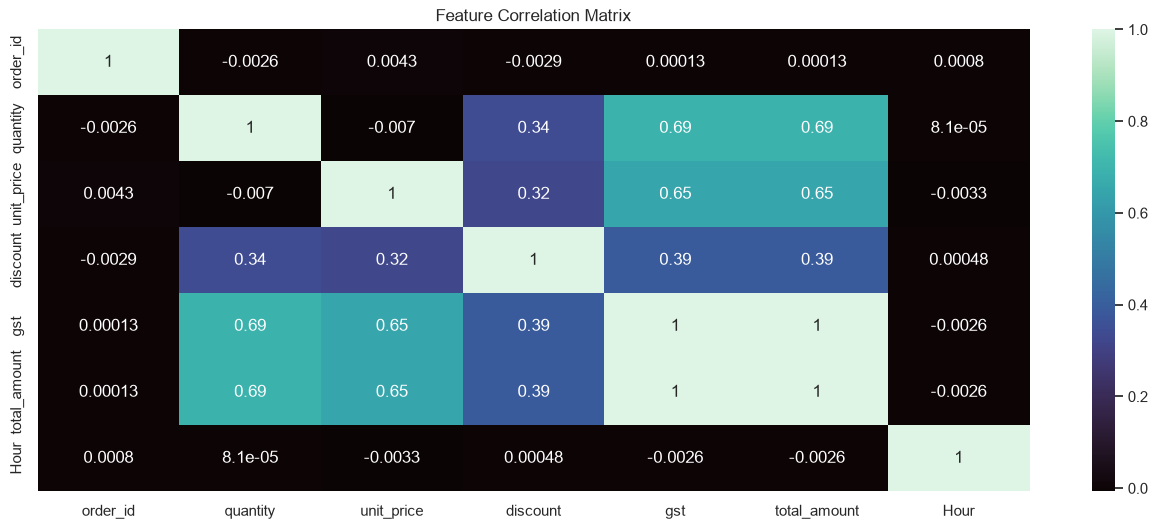

In [54]:
plt.figure(figsize=(16,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="mako")
plt.title("Feature Correlation Matrix")
plt.show()

## Conclusion: 
Confirms whether metrics move in tandem (positive/negative correlation) or operate independently.